# Exploratory Data Analysis

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/grievances.csv")

df.head()

,complaint,department,sentiment
0,Water supply not available for 3 days,Water,Critical
1,Street light not working,Roads,Negative
2,Power outage in sector 10,Electricity,Critical
3,Garbage not collected for a week,Sanitation,Negative
4,Water leakage near main road,Water,Negative


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   complaint   10 non-null     str  
 1   department  10 non-null     str  
 2   sentiment   10 non-null     str  
dtypes: str(3)
memory usage: 793.0 bytes


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10
Columns: 3


In [4]:
df.isnull().sum()

complaint     0
department    0
sentiment     0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["cleaned_text"] = df["complaint"].apply(clean_text)

df.head()

,complaint,department,sentiment,cleaned_text
0,Water supply not available for 3 days,Water,Critical,water supply not available for days
1,Street light not working,Roads,Negative,street light not working
2,Power outage in sector 10,Electricity,Critical,power outage in sector
3,Garbage not collected for a week,Sanitation,Negative,garbage not collected for a week
4,Water leakage near main road,Water,Negative,water leakage near main road


In [7]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pradipsinh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["cleaned_text"] = df["cleaned_text"].apply(remove_stopwords)

In [9]:
import spacy

nlp = spacy.load("en_core_web_sm")

def lemmatize_text(text):
    doc = nlp(text)
    return " ".join(
        [token.lemma_ for token in doc]
    )

df["cleaned_text"] = df["cleaned_text"].apply(lemmatize_text)

df.head()

,complaint,department,sentiment,cleaned_text
0,Water supply not available for 3 days,Water,Critical,water supply available day
1,Street light not working,Roads,Negative,street light work
2,Power outage in sector 10,Electricity,Critical,power outage sector
3,Garbage not collected for a week,Sanitation,Negative,garbage collect week
4,Water leakage near main road,Water,Negative,water leakage near main road


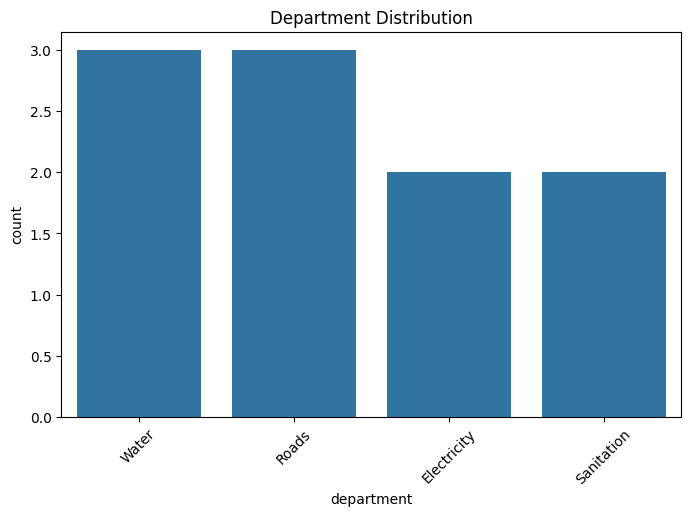

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="department"
)

plt.xticks(rotation=45)

plt.title("Department Distribution")

plt.show()

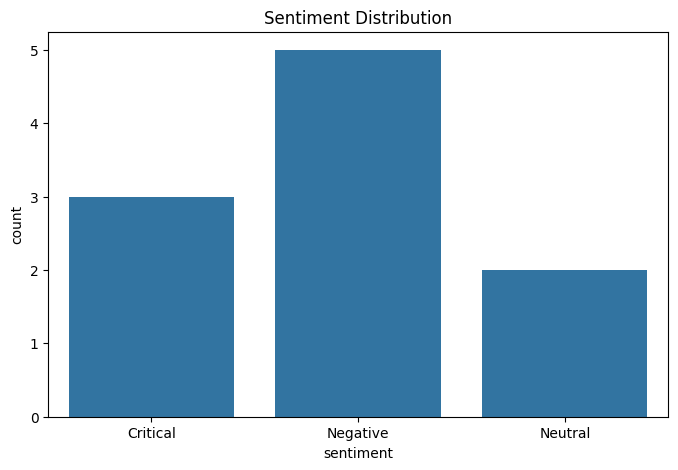

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Distribution")

plt.show()

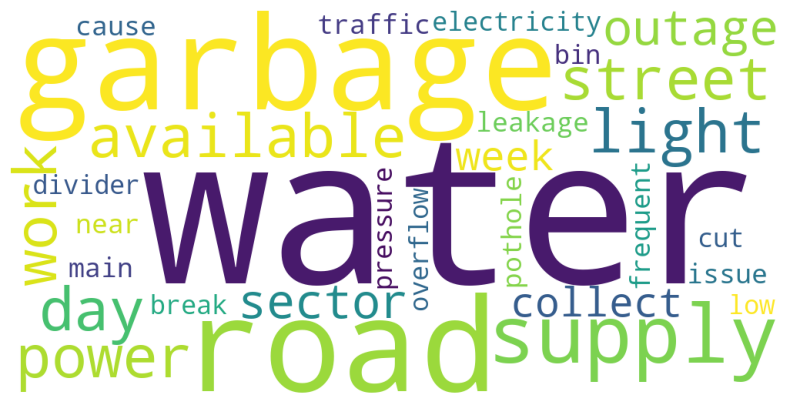

In [12]:
from wordcloud import WordCloud

text = " ".join(df["cleaned_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english"
)

X = vectorizer.fit_transform(
    df["cleaned_text"]
)

bigrams = vectorizer.get_feature_names_out()

print(bigrams[:20])

['available day' 'break road' 'cause traffic' 'collect week'
 'electricity cut' 'frequent electricity' 'garbage bin' 'garbage collect'
 'leakage near' 'light work' 'main road' 'near main' 'outage sector'
 'overflow garbage' 'pothole cause' 'power outage' 'pressure low'
 'road divider' 'street light' 'supply available']


In [14]:
vectorizer = CountVectorizer(
    ngram_range=(3,3),
    stop_words="english"
)

X = vectorizer.fit_transform(
    df["cleaned_text"]
)

trigrams = vectorizer.get_feature_names_out()

print(trigrams[:20])

['break road divider' 'cause traffic issue' 'frequent electricity cut'
 'garbage collect week' 'leakage near main' 'near main road'
 'overflow garbage bin' 'pothole cause traffic' 'power outage sector'
 'street light work' 'supply available day' 'water leakage near'
 'water pressure low' 'water supply available']


In [15]:
df.to_csv(
    "../data/processed/cleaned_grievances.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully
